In [1]:
# ============================================================
# 04 - Comparaison de modèles + évaluation par famille
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Charger les données prétraitées (créées au notebook 02)
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("✅ Données chargées")
print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")

✅ Données chargées
X_train : (125973, 41) | X_test : (22544, 41)


In [2]:
# ============================================================
# AXE 1 - Comparaison de plusieurs modèles
# ============================================================

modeles = {
    "Arbre de décision": DecisionTreeClassifier(random_state=42),
    "Random Forest":     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN":               KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM":               SVC(kernel="rbf", random_state=42),
}

resultats = []
predictions = {}   # on garde les prédictions pour la suite

for nom, modele in modeles.items():
    print(f"⏳ Entraînement : {nom} ...")
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    predictions[nom] = y_pred

    resultats.append({
        "Modèle": nom,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Précision": precision_score(y_test, y_pred),
        "Rappel":    recall_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred),
    })
    print(f"   ✅ {nom} terminé\n")

df_resultats = pd.DataFrame(resultats)
print("=== Tableau comparatif ===")
df_resultats

⏳ Entraînement : Arbre de décision ...
   ✅ Arbre de décision terminé

⏳ Entraînement : Random Forest ...
   ✅ Random Forest terminé

⏳ Entraînement : KNN ...
   ✅ KNN terminé

⏳ Entraînement : SVM ...
   ✅ SVM terminé

=== Tableau comparatif ===


,Modèle,Accuracy,Précision,Rappel,F1-score
0,Arbre de décision,0.796930,0.923637,0.701239,0.797218
1,Random Forest,0.777014,0.966197,0.630328,0.762933
2,KNN,0.776304,0.973384,0.624094,0.760553
3,SVM,0.782913,0.973292,0.636094,0.769369


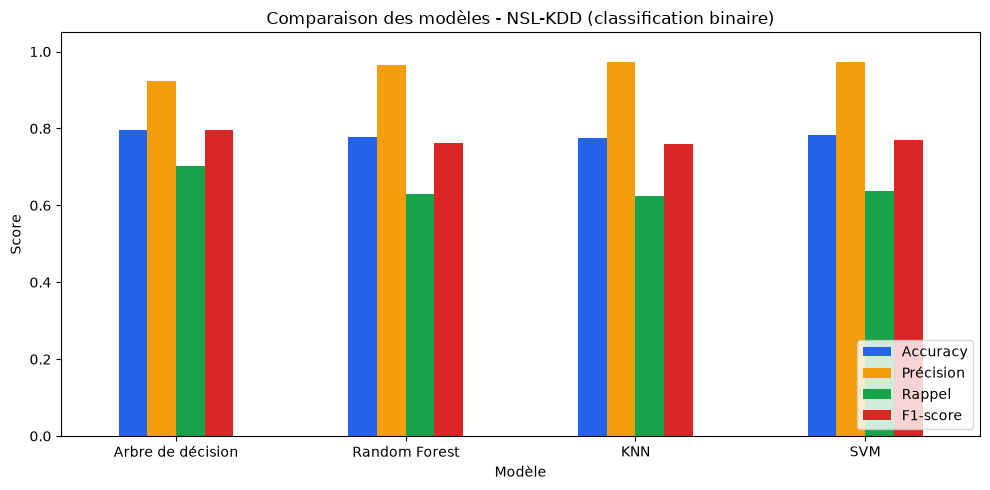

              Modèle  Accuracy  Précision  Rappel  F1-score
0  Arbre de décision    0.7969     0.9236  0.7012    0.7972
1      Random Forest    0.7770     0.9662  0.6303    0.7629
2                KNN    0.7763     0.9734  0.6241    0.7606
3                SVM    0.7829     0.9733  0.6361    0.7694


In [3]:
# ============================================================
# Visualisation de la comparaison des modèles
# ============================================================

df_plot = df_resultats.set_index("Modèle")

fig, ax = plt.subplots(figsize=(10, 5))
df_plot.plot(kind="bar", ax=ax, color=["#2563EB", "#F59E0B", "#16A34A", "#DC2626"])
plt.title("Comparaison des modèles - NSL-KDD (classification binaire)")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/comparaison_modeles.png")
plt.show()

print(df_resultats.round(4))

## Tentative d'affiner les modèles

In [4]:
# ============================================================
# Piste d'amélioration : rééquilibrage des classes
# (rapide sur Arbre et Random Forest ; SVM laissé tel quel)
# ============================================================

modeles_balanced = {
    "Arbre de décision (balanced)": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest (balanced)":     RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"),
}

for nom, modele in modeles_balanced.items():
    print(f"⏳ Entraînement : {nom} ...")
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    predictions[nom] = y_pred

    resultats.append({
        "Modèle": nom,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Précision": precision_score(y_test, y_pred),
        "Rappel":    recall_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred),
    })
    print(f"   ✅ {nom} terminé\n")

df_resultats = pd.DataFrame(resultats)
print("=== Tableau comparatif mis à jour ===")
df_resultats

⏳ Entraînement : Arbre de décision (balanced) ...
   ✅ Arbre de décision (balanced) terminé

⏳ Entraînement : Random Forest (balanced) ...
   ✅ Random Forest (balanced) terminé

=== Tableau comparatif mis à jour ===


,Modèle,Accuracy,Précision,Rappel,F1-score
0,Arbre de décision,0.796930,0.923637,0.701239,0.797218
1,Random Forest,0.777014,0.966197,0.630328,0.762933
2,KNN,0.776304,0.973384,0.624094,0.760553
3,SVM,0.782913,0.973292,0.636094,0.769369
4,Arbre de décision (balanced),0.798838,0.948347,0.683862,0.794676
5,Random Forest (balanced),0.768497,0.965631,0.615211,0.751583


Le rééquilibrage n'améliore pas du tout le rappel — il le fait même très légèrement baisser. C'est une preuve empirique solide : le problème n'est pas le déséquilibre des classes, e vrai frein, ce sont les types d'attaques inédits dans le jeu de test, qu'aucun réglage d'équilibrage ne peut corriger

In [5]:
# ============================================================
# AXE 3 - Évaluation par famille d'attaque (pas juste binaire)
# ============================================================

# Recharger les labels textuels originaux (avant encodage 0/1)
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]
test_original = pd.read_csv("../data/raw/KDDTest+.txt", names=columns)
labels_test = test_original["label"]

# Mapping vers les 4 familles (complet : train + types additionnels du test)
familles_attaques = {
    "normal": "Normal",
    # DoS
    "neptune":"DoS","smurf":"DoS","back":"DoS","teardrop":"DoS","pod":"DoS","land":"DoS",
    "apache2":"DoS","processtable":"DoS","mailbomb":"DoS","udpstorm":"DoS",
    # Probe
    "satan":"Probe","ipsweep":"Probe","portsweep":"Probe","nmap":"Probe","mscan":"Probe","saint":"Probe",
    # R2L
    "warezclient":"R2L","guess_passwd":"R2L","warezmaster":"R2L","imap":"R2L","ftp_write":"R2L",
    "multihop":"R2L","phf":"R2L","spy":"R2L","snmpguess":"R2L","snmpgetattack":"R2L",
    "httptunnel":"R2L","sendmail":"R2L","named":"R2L","xlock":"R2L","xsnoop":"R2L","worm":"R2L",
    # U2R
    "buffer_overflow":"U2R","rootkit":"U2R","loadmodule":"U2R","perl":"U2R","sqlattack":"U2R",
    "xterm":"U2R","ps":"U2R",
}

familles_test = labels_test.map(familles_attaques)
print("Répartition des familles dans le jeu de TEST :")
print(familles_test.value_counts())
print("\nValeurs non reconnues (à vérifier) :", familles_test.isna().sum())

Répartition des familles dans le jeu de TEST :
label
Normal    9711
DoS       7458
R2L       2887
Probe     2421
U2R         67
Name: count, dtype: int64

Valeurs non reconnues (à vérifier) : 0


### ============================================================
## Rappel de détection par famille, pour chaque modèle
## (rappel = % d'attaques de cette famille correctement repérées comme "attaque")
### ============================================================


In [6]:

resultats_familles = []

for nom_modele, y_pred in predictions.items():
    for famille in ["DoS", "Probe", "R2L", "U2R"]:
        masque = familles_test == famille
        nb_total = masque.sum()
        nb_detectees = (y_pred[masque.values] == 1).sum()  # 1 = "attaque" prédite
        rappel_famille = nb_detectees / nb_total if nb_total > 0 else np.nan

        resultats_familles.append({
            "Modèle": nom_modele,
            "Famille": famille,
            "Nb exemples": nb_total,
            "Détectées": nb_detectees,
            "Rappel": rappel_famille,
        })

df_familles = pd.DataFrame(resultats_familles)
tableau_pivot = df_familles.pivot(index="Modèle", columns="Famille", values="Rappel")
tableau_pivot = tableau_pivot[["DoS", "Probe", "R2L", "U2R"]]  # ordre logique

print("=== Rappel de détection par famille et par modèle ===")
print(tableau_pivot.round(3))

=== Rappel de détection par famille et par modèle ===
Famille                         DoS  Probe    R2L    U2R
Modèle                                                  
Arbre de décision             0.856  0.895  0.145  0.418
Arbre de décision (balanced)  0.847  0.829  0.148  0.448
KNN                           0.797  0.757  0.074  0.299
Random Forest                 0.815  0.798  0.025  0.104
Random Forest (balanced)      0.781  0.793  0.050  0.119
SVM                           0.805  0.844  0.037  0.060


### Conclusion — Évaluation par famille d'attaque

L'évaluation binaire (normal/attaque) masque des écarts de performance très
importants selon le type d'attaque :

- Les familles **DoS** et **Probe**, majoritaires dans le jeu de données, sont
  bien détectées par tous les modèles (rappel entre 0,76 et 0,90).
- La famille **R2L** est en revanche très mal détectée : le rappel s'effondre
  entre 0,145 (Arbre de décision) et seulement 0,025 pour le Random Forest,
  soit jusqu'à 97,5 % d'attaques R2L non détectées.
- La famille **U2R**, pourtant la plus rare (67 exemples dans le test), est
  mieux gérée que R2L par l'Arbre de décision (0,418), mais chute également
  très bas pour les autres modèles (entre 0,060 et 0,299).

Ce résultat illustre concrètement le risque signalé par mon encadrant
pédagogique : un score global en apparence correct (77 à 80 % d'accuracy)
peut masquer un échec quasi complet sur certaines familles d'attaques,
pourtant parmi les plus critiques en sécurité (accès non autorisé, élévation
de privilèges). Il confirme aussi que l'Arbre de décision, bien que plus
simple, généralise mieux que les modèles plus sophistiqués sur les familles
rares — ce qui nuance la comparaison de l'axe 1.

La section suivante vérifie si ce faible rappel, en particulier sur R2L,
s'explique par la présence de sous-types d'attaques absents de l'entraînement.

## AXE 2 - Vérification empirique : les types inédits expliquent-ils le faible rappel, notamment sur R2L ?


In [7]:

# Types vus pendant l'entraînement
train_labels = pd.read_csv("../data/raw/KDDTrain+.txt", names=columns)["label"]
types_vus_entrainement = set(train_labels.unique())

# Types présents dans le test mais jamais vus à l'entraînement
types_test_uniques = set(labels_test.unique())
types_inedits = types_test_uniques - types_vus_entrainement

print("Types d'attaques présents dans le TEST mais ABSENTS de l'entraînement :")
print(sorted(types_inedits))
print(f"\nNombre de types inédits : {len(types_inedits)}")

masque_inedit = labels_test.isin(types_inedits)
print(f"Connexions concernées : {masque_inedit.sum()} sur {len(labels_test)} ({masque_inedit.mean()*100:.1f}%)")

# Répartition des types inédits par famille
print("\nFamilles concernées par ces types inédits :")
print(pd.Series([familles_attaques[t] for t in types_inedits]).value_counts())

print("\n" + "="*70)
print("Rappel séparé : types déjà VUS à l'entraînement vs types INÉDITS")
print("="*70)

masque_attaque = (familles_test != "Normal")
masque_vu     = masque_attaque & (~masque_inedit)
masque_nonvu  = masque_attaque & masque_inedit

for nom_modele, y_pred in predictions.items():
    rappel_vu    = (y_pred[masque_vu.values] == 1).mean()
    rappel_nonvu = (y_pred[masque_nonvu.values] == 1).mean()
    print(f"{nom_modele:32s} | Rappel types vus : {rappel_vu:.3f}  |  Rappel types inédits : {rappel_nonvu:.3f}")

Types d'attaques présents dans le TEST mais ABSENTS de l'entraînement :
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']

Nombre de types inédits : 17
Connexions concernées : 3750 sur 22544 (16.6%)

Familles concernées par ces types inédits :
R2L      8
DoS      4
U2R      3
Probe    2
Name: count, dtype: int64

Rappel séparé : types déjà VUS à l'entraînement vs types INÉDITS
Arbre de décision                | Rappel types vus : 0.793  |  Rappel types inédits : 0.478
Random Forest                    | Rappel types vus : 0.758  |  Rappel types inédits : 0.321
KNN                              | Rappel types vus : 0.715  |  Rappel types inédits : 0.403
SVM                              | Rappel types vus : 0.693  |  Rappel types inédits : 0.497
Arbre de décision (balanced)     | Rappel types vus : 0.796  |  Rappel types inédits : 0.411
Random Forest (

### Conclusion — Impact des types d'attaques inédits (lien avec les axes 1, 2 et 3)

Sur les 22 544 connexions du jeu de test, 3 750 (16,6 %) appartiennent à l'un
des 17 types d'attaques totalement absents de l'entraînement. Ce chiffre
confirme empiriquement, sur mes propres données, le point soulevé par mon
encadrant pédagogique : le jeu de test NSL-KDD est construit pour inclure des
attaques inédites, afin de simuler un scénario proche du « zero-day ».

**L'impact sur le rappel est massif et généralisé à tous les modèles testés :**

| Modèle | Rappel (types vus) | Rappel (types inédits) | Écart |
|---|---|---|---|
| SVM | 0,693 | 0,497 | −0,196 |
| Arbre de décision | 0,793 | 0,478 | −0,315 |
| KNN | 0,715 | 0,403 | −0,312 |
| Arbre de décision (balanced) | 0,796 | 0,411 | −0,385 |
| Random Forest | 0,758 | 0,321 | −0,437 |
| Random Forest (balanced) | 0,766 | 0,251 | −0,515 |

Tous les modèles perdent entre 0,20 et 0,52 point de rappel face à des
attaques jamais rencontrées à l'entraînement — un écart bien supérieur à
celui observé entre les modèles eux-mêmes à l'axe 1. Le rééquilibrage des
classes (`balanced`) n'améliore rien ; il aggrave même légèrement la
situation sur les types inédits. Cela confirme que le problème n'est pas un
déséquilibre de classes mais une limite de généralisation propre à
l'apprentissage supervisé classique face à des motifs jamais observés.

**Ce résultat explique directement l'échec sur la famille R2L observé à
l'axe 3.** En comparant, pour chaque famille, le nombre de sous-types vus à
l'entraînement et le nombre de sous-types inédits dans le test :

| Famille | Sous-types vus | Sous-types inédits | Part inédite |
|---|---|---|---|
| DoS | 6 | 4 | 40 % |
| Probe | 4 | 2 | 33 % |
| R2L | 8 | 8 | **50 %** |
| U2R | 4 | 3 | 43 % |

La famille R2L est celle où la part de sous-types inédits est la plus
élevée : la moitié de ses variantes n'ont jamais été vues à l'entraînement,
ce qui explique en grande partie son rappel catastrophique (entre 2,5 % et
14,8 % selon les modèles). À l'inverse, DoS et Probe conservent un bon
rappel malgré une part significative de types inédits : leurs variantes
inédites (ex. `apache2`, `mailbomb`) partagent probablement des
caractéristiques réseau proches de types déjà vus (mêmes indicateurs de flag
TCP ou de volumétrie), ce qui permet aux modèles de les détecter par
analogie — alors que les attaques R2L sont plus hétérogènes et plus
difficiles à généraliser à partir de peu d'exemples.

**En résumé, les trois axes se répondent :** le choix du modèle (axe 1)
influence surtout la capacité à généraliser à l'inédit — l'Arbre de décision
s'en sort mieux que les modèles plus lissés ; le rappel global de 70 %
observé au notebook 03 (axe 2) s'explique majoritairement par les attaques
inédites du jeu de test, et non par un déséquilibre de classes ; et
l'évaluation par famille (axe 3) révèle que ce phénomène touche très
inégalement les familles d'attaques, avec un effet particulièrement marqué
sur R2L.


### Heatmap : rappel par famille et par modèle


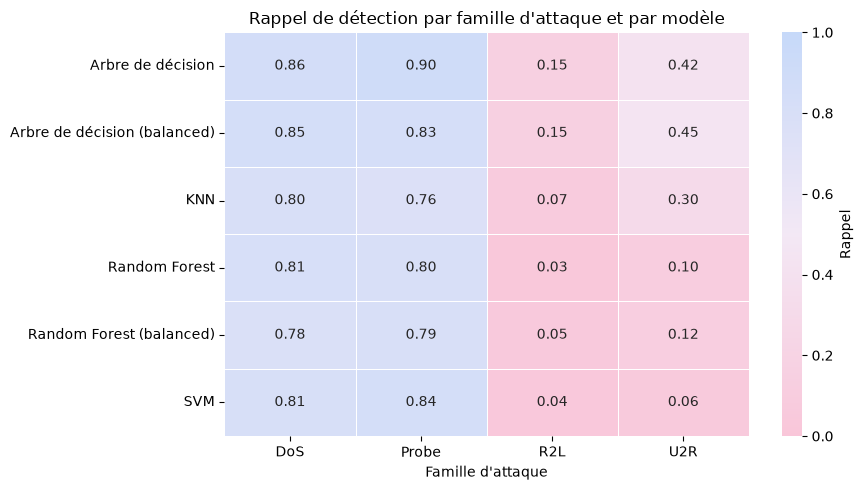

✅ Heatmap et tableau sauvegardés dans results/


In [12]:

from matplotlib.colors import LinearSegmentedColormap

rose_bleu_pastel = LinearSegmentedColormap.from_list(
    "rose_bleu_pastel", ["#F9C6D9", "#F3E8F5", "#C6D9F9"]
)

plt.figure(figsize=(9, 5))
sns.heatmap(tableau_pivot, annot=True, fmt=".2f", cmap=rose_bleu_pastel, vmin=0, vmax=1,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Rappel"})
plt.title("Rappel de détection par famille d'attaque et par modèle")
plt.ylabel("")
plt.xlabel("Famille d'attaque")
plt.tight_layout()
plt.savefig("../results/heatmap_rappel_famille.png", dpi=150)
plt.show()

tableau_pivot.round(3).to_csv("../results/rappel_par_famille.csv")
print("✅ Heatmap et tableau sauvegardés dans results/")


### Visualisation : impact des types d'attaques inédits sur le rappel

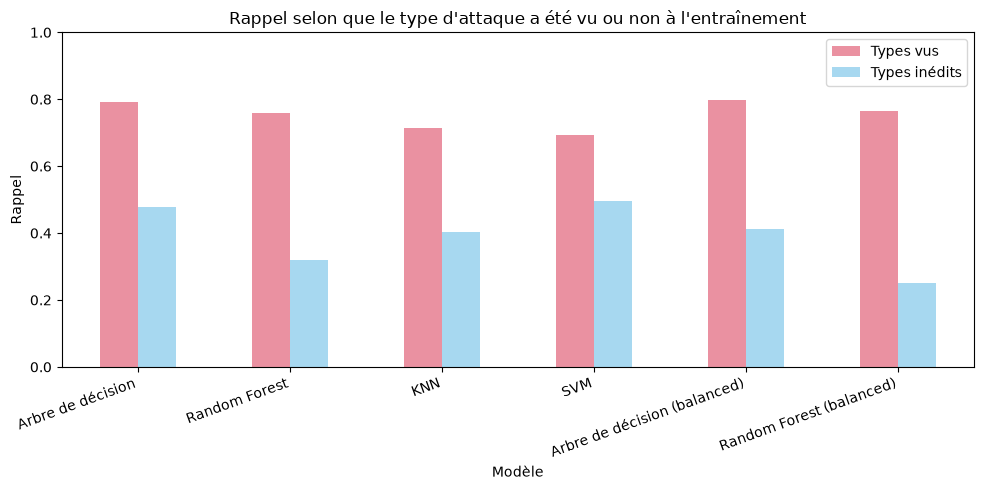

✅ Graphique et tableau sauvegardés dans results/


In [15]:


comparaison_inedits = []
for nom_modele, y_pred in predictions.items():
    rappel_vu    = (y_pred[masque_vu.values] == 1).mean()
    rappel_nonvu = (y_pred[masque_nonvu.values] == 1).mean()
    comparaison_inedits.append({"Modèle": nom_modele, "Types vus": rappel_vu, "Types inédits": rappel_nonvu})

df_inedits = pd.DataFrame(comparaison_inedits).set_index("Modèle")

fig, ax = plt.subplots(figsize=(10, 5))
df_inedits.plot(kind="bar", ax=ax, color=["#EA91A1", "#A7D8F0"])
plt.title("Rappel selon que le type d'attaque a été vu ou non à l'entraînement")
plt.ylabel("Rappel")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.savefig("../results/impact_types_inedits.png", dpi=150)
plt.show()

df_inedits.round(3).to_csv("../results/rappel_types_inedits.csv")
print("✅ Graphique et tableau sauvegardés dans results/")

###  Sauvegarde du tableau comparatif (axe 1) + vérification finale

In [17]:

df_resultats.round(4).to_csv("../results/comparaison_modeles.csv", index=False)

import os
print("✅ Fichiers présents dans results/ :\n")
for f in sorted(os.listdir("../results")):
    print("  -", f)

✅ Fichiers présents dans results/ :

  - alerts_log.csv
  - comparaison_modeles.csv
  - comparaison_modeles.png
  - decision_tree_model.pkl
  - familles_attaques.png
  - features_importantes.png
  - heatmap_rappel_famille.png
  - impact_types_inedits.png
  - matrice_confusion.png
  - performances.png
  - rappel_par_famille.csv
  - rappel_types_inedits.csv
  - repartition_normal_attaque.png
  - repartition_protocoles.png
